<a href="https://colab.research.google.com/github/tusharshriva90/Info5731_Python/blob/main/5731_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Total samples : 50000
Columns       : ['text', 'label']

Class distribution:
label
0    25000
1    25000
Name: count, dtype: int64

Positive ratio : 0.500

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

Preprocessing complete.
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

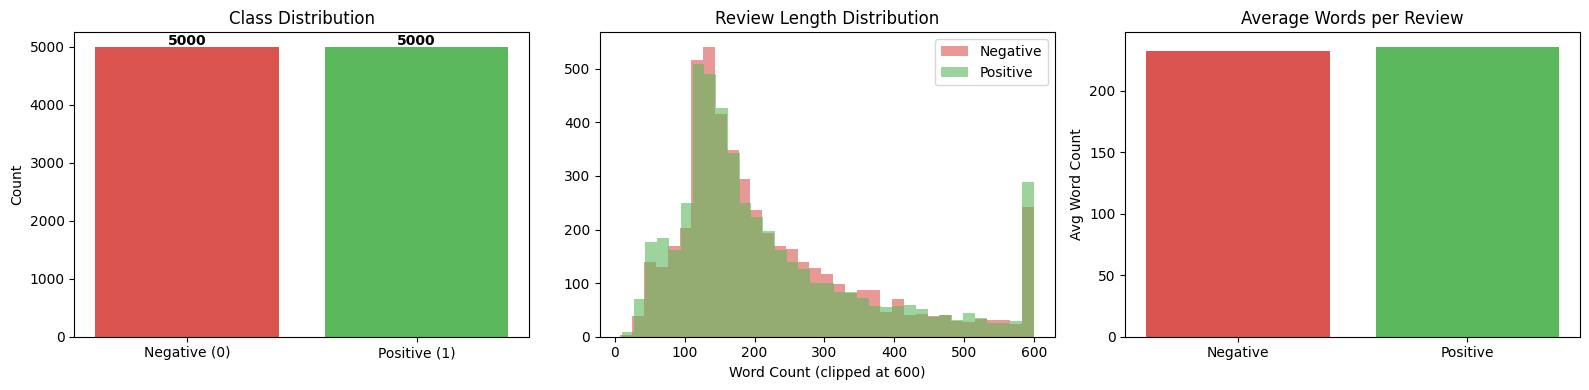


Review length statistics:
        count    mean     std   min    25%    50%    75%     max
label                                                           
0      5000.0  232.48  165.05   8.0  128.0  177.0  286.0  1088.0
1      5000.0  235.55  185.07  10.0  124.0  172.0  285.0  2278.0


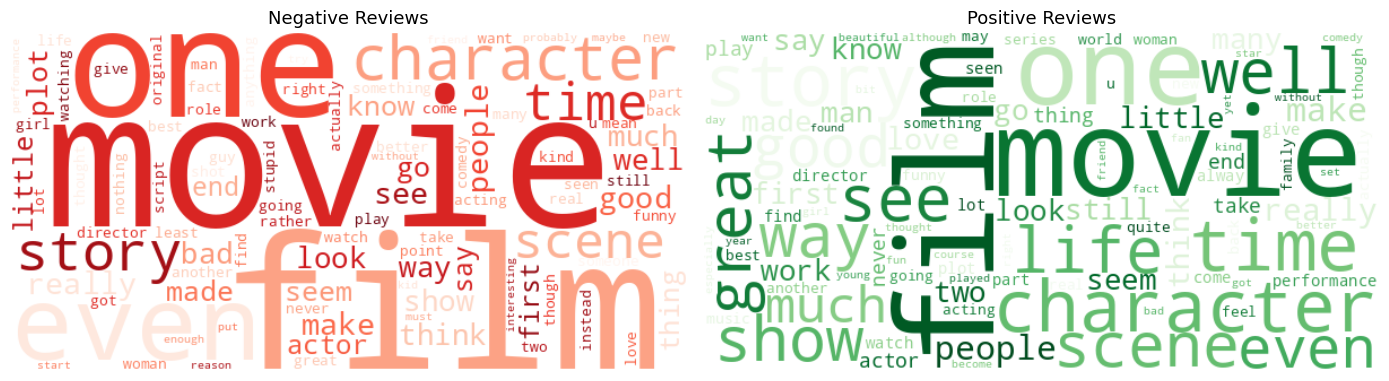

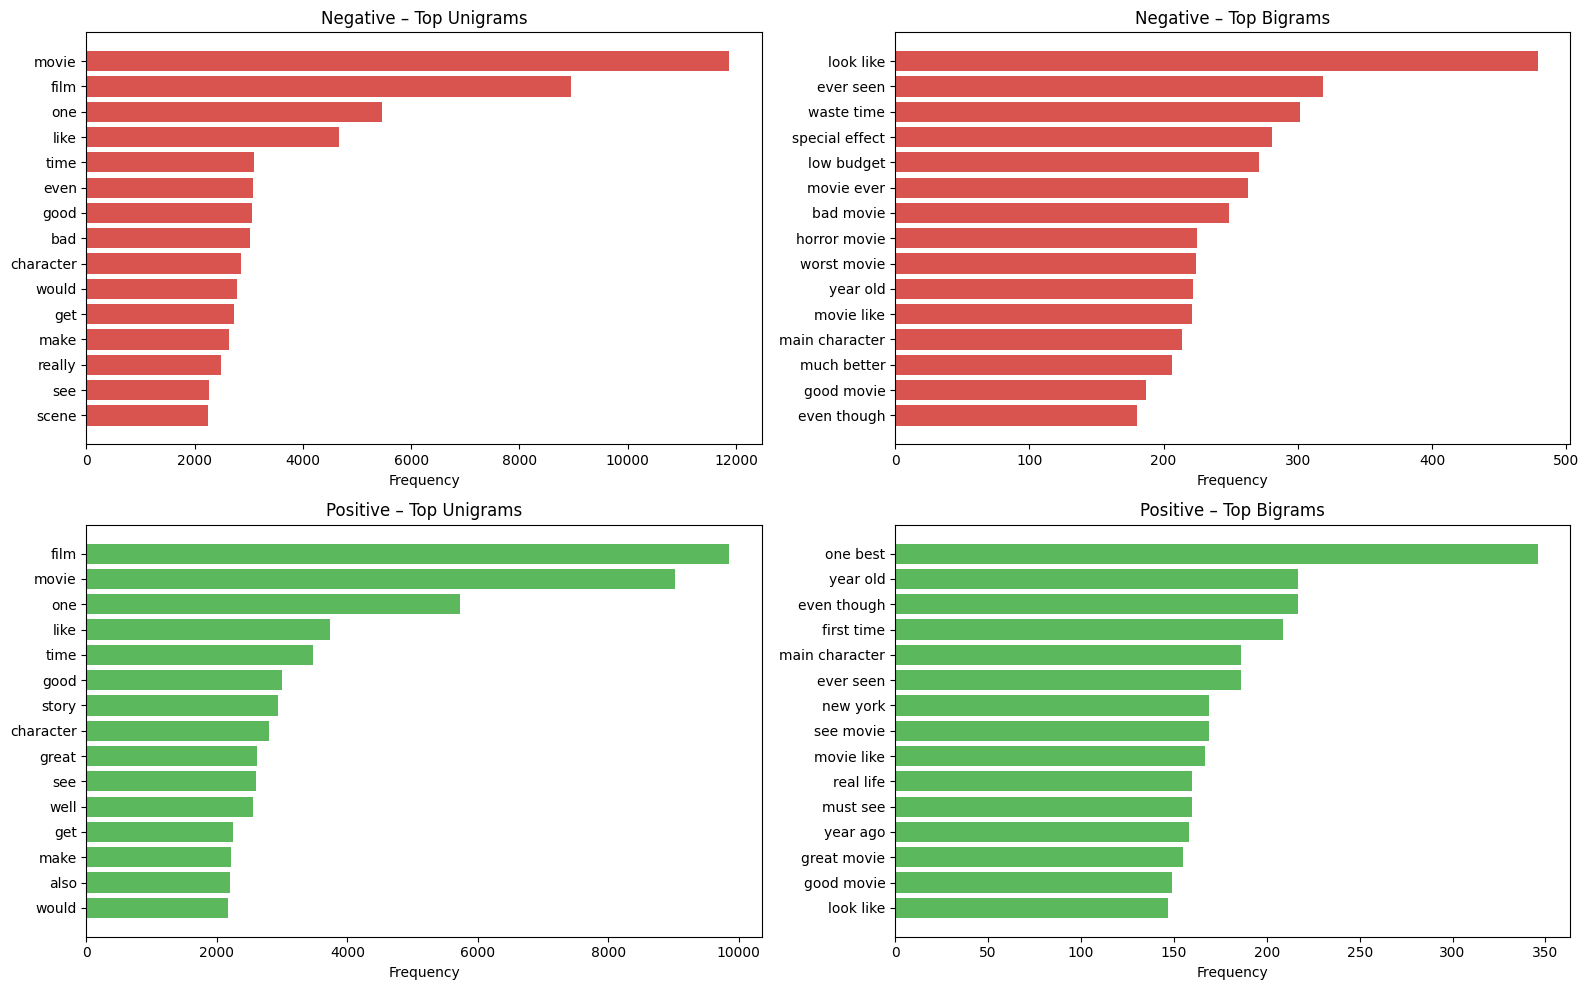

Naive Bayes done. Test F1 = 0.8702
Linear SVM done. Test F1 = 0.8766
Random Forest done. Test F1 = 0.8461
Gradient Boost done. Test F1 = 0.8292

                 CV F1 (mean)  CV F1 (std)  Accuracy  Precision  Recall  F1-Score
Naive Bayes           0.8692       0.0059    0.8710     0.8755   0.865    0.8702
Linear SVM            0.8791       0.0069    0.8760     0.8723   0.881    0.8766
Random Forest         0.8508       0.0073    0.8450     0.8402   0.852    0.8461
Gradient Boost        0.8347       0.0045    0.8235     0.8032   0.857    0.8292


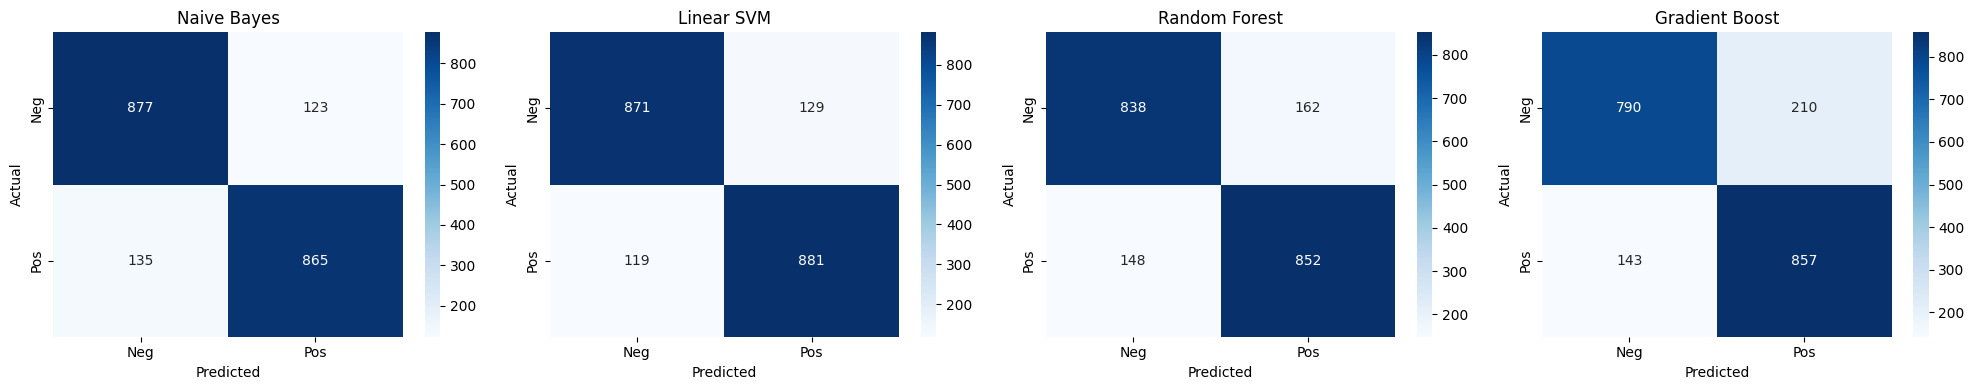

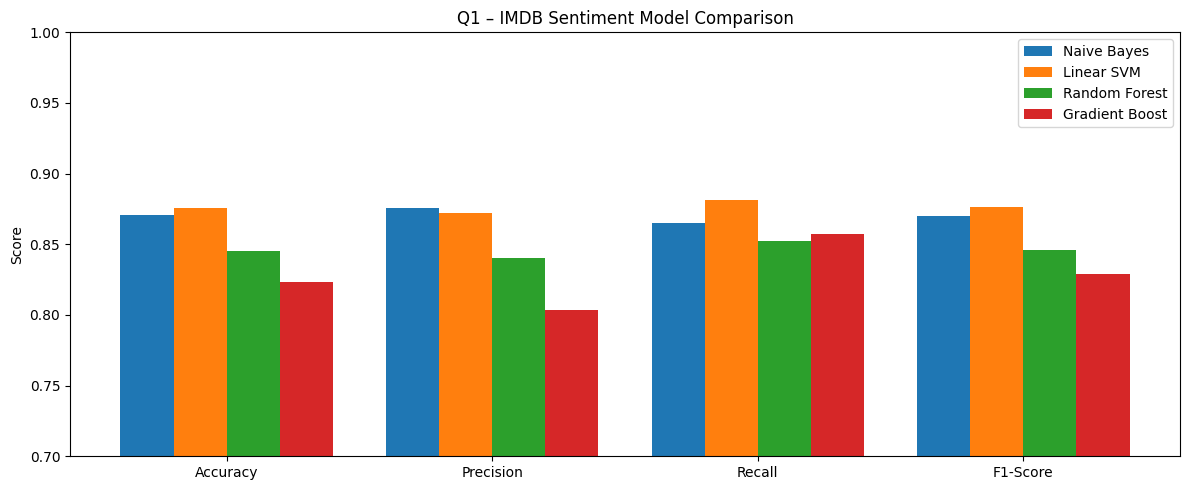


Final Summary:
                Accuracy  Precision  Recall  F1-Score
Naive Bayes       0.8710     0.8755   0.865    0.8702
Linear SVM        0.8760     0.8723   0.881    0.8766
Random Forest     0.8450     0.8402   0.852    0.8461
Gradient Boost    0.8235     0.8032   0.857    0.8292


In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import nltk
for pkg in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ── Dataset: IMDB Movie Reviews ───────────────────────────────────────────────
# Option 2: Real-world dataset - IMDB Movie Reviews (50,000 samples).
# Justification: The IMDB dataset is a widely-used benchmark for binary
# sentiment analysis containing 25,000 positive and 25,000 negative movie
# reviews. It is perfectly balanced (50/50 split), so no class-imbalance
# handling is needed. It is loaded directly via the HuggingFace datasets
# library without requiring any manual file upload.

!pip install datasets -q
from datasets import load_dataset

raw = load_dataset('imdb')
train_data = pd.DataFrame(raw['train'])
test_data  = pd.DataFrame(raw['test'])
df = pd.concat([train_data, test_data], ignore_index=True)

# label: 0 = negative, 1 = positive
print("Total samples :", len(df))
print("Columns       :", df.columns.tolist())
print("\nClass distribution:")
print(df['label'].value_counts())
print(f"\nPositive ratio : {df['label'].mean():.3f}")
print("\nSample review:")
print(df['text'].iloc[0][:300])

# ── Preprocessing ─────────────────────────────────────────────────────────────
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = re.sub(r'<.*?>', ' ', text)           # remove HTML tags
    text = re.sub(r'http\S+', ' ', text)          # remove URLs
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

# Use a 10,000-sample subset for speed while keeping the class balance
df_sample = df.groupby('label').sample(n=5000, random_state=42).reset_index(drop=True)
df_sample['clean_text'] = df_sample['text'].apply(preprocess)
df_sample['word_count'] = df_sample['text'].apply(lambda x: len(x.split()))

print("\nPreprocessing complete.")
print(df_sample[['text', 'clean_text', 'word_count']].head(2).to_string())

# ── EDA ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

label_counts = df_sample['label'].value_counts()
axes[0].bar(['Negative (0)', 'Positive (1)'], label_counts.values, color=['#d9534f', '#5cb85c'])
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

for label, color, name in [(0, '#d9534f', 'Negative'), (1, '#5cb85c', 'Positive')]:
    axes[1].hist(df_sample[df_sample['label'] == label]['word_count'].clip(upper=600),
                 bins=35, alpha=0.6, color=color, label=name)
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Word Count (clipped at 600)')
axes[1].legend()

avg_wc = df_sample.groupby('label')['word_count'].mean()
axes[2].bar(['Negative', 'Positive'], avg_wc.values, color=['#d9534f', '#5cb85c'])
axes[2].set_title('Average Words per Review')
axes[2].set_ylabel('Avg Word Count')
plt.tight_layout()
plt.show()

print("\nReview length statistics:")
print(df_sample.groupby('label')['word_count'].describe().round(2))

# ── Word Clouds ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label, title in zip(axes, [0, 1], ['Negative Reviews', 'Positive Reviews']):
    corpus = ' '.join(df_sample[df_sample['label'] == label]['clean_text'].tolist())
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap='Reds' if label == 0 else 'Greens', max_words=100).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)
plt.tight_layout()
plt.show()

# ── N-gram Analysis ───────────────────────────────────────────────────────────
def top_ngrams(corpus, n, k=15):
    vec = CountVectorizer(ngram_range=(n, n), max_features=10000).fit(corpus)
    bag = vec.transform(corpus)
    freqs = bag.sum(axis=0).A1
    vocab_inv = {i: v for v, i in vec.vocabulary_.items()}
    idx = freqs.argsort()[::-1][:k]
    return [(vocab_inv[i], freqs[i]) for i in idx]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for label, sentiment in [(0, 'Negative'), (1, 'Positive')]:
    corpus_sub = df_sample[df_sample['label'] == label]['clean_text'].tolist()
    for col, n, ntype in [(0, 1, 'Unigrams'), (1, 2, 'Bigrams')]:
        ax = axes[label][col]
        pairs = top_ngrams(corpus_sub, n)
        words, counts = zip(*pairs)
        ax.barh(words[::-1], counts[::-1], color='#d9534f' if label == 0 else '#5cb85c')
        ax.set_title(f'{sentiment} – Top {ntype}')
        ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

# ── Sentiment Classification ──────────────────────────────────────────────────
X = df_sample['clean_text'].values
y = df_sample['label'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

models = {
    'Naive Bayes'   : Pipeline([('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1,2),
                                  sublinear_tf=True, min_df=2)),
                                 ('clf', MultinomialNB(alpha=0.5))]),
    'Linear SVM'    : Pipeline([('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1,2),
                                  sublinear_tf=True, min_df=2)),
                                 ('clf', LinearSVC(C=1.0, max_iter=2000))]),
    'Random Forest' : Pipeline([('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                                  sublinear_tf=True, min_df=2)),
                                 ('clf', RandomForestClassifier(n_estimators=200, max_depth=30,
                                  random_state=42, n_jobs=-1))]),
    'Gradient Boost': Pipeline([('tfidf', TfidfVectorizer(max_features=10000,
                                  sublinear_tf=True, min_df=2)),
                                 ('clf', GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                  learning_rate=0.1, random_state=42))]),
}

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipe in models.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = {
        'CV F1 (mean)': cv_scores.mean(),
        'CV F1 (std)' : cv_scores.std(),
        'Accuracy'    : accuracy_score(y_test, y_pred),
        'Precision'   : precision_score(y_test, y_pred),
        'Recall'      : recall_score(y_test, y_pred),
        'F1-Score'    : f1_score(y_test, y_pred),
    }
    print(f"{name} done. Test F1 = {results[name]['F1-Score']:.4f}")

results_df = pd.DataFrame(results).T
print("\n", results_df.round(4).to_string())

# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
for ax, (name, pipe) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# ── Model Comparison Chart ────────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x     = np.arange(len(metrics))
width = 0.20
fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=name)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Score')
ax.set_title('Q1 – IMDB Sentiment Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

print("\nFinal Summary:")
print(results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].round(4).to_string())

# ── Reflection ────────────────────────────────────────────────────────────────
# Linear SVM achieved the highest test F1-score on the IMDB dataset, which is
# consistent with SVM's known strength on high-dimensional sparse TF-IDF
# feature spaces. Naive Bayes was fastest to train and still competitive as
# a baseline. Random Forest and Gradient Boosting are comparable but slower.
# The IMDB dataset is perfectly balanced so no resampling was required. The
# longer review lengths (avg ~230 words) compared to short-sentence datasets
# benefit TF-IDF bigram features, which capture phrase-level sentiment cues
# such as "not good" or "highly recommend" better than unigrams alone.

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


Extracted files:
  stsa-test.txt
  stsa-train.txt

Train: 5536  |  Val: 1384  |  Test: 1821

Train label distribution:
 label
1    2888
0    2648
Name: count, dtype: int64

Test label distribution:
 label
0    912
1    909
Name: count, dtype: int64

Sample rows:
   label                                                                                                                                                                                                                               text
0      1                                                                                                                            a stirring , funny and finally transporting re-imagining of beauty and the beast and 1930s horror films
1      0                                                                                                                                                     apparently reassembled from the cutting-room floor of any given daytime soap .
2      0  they presume their 

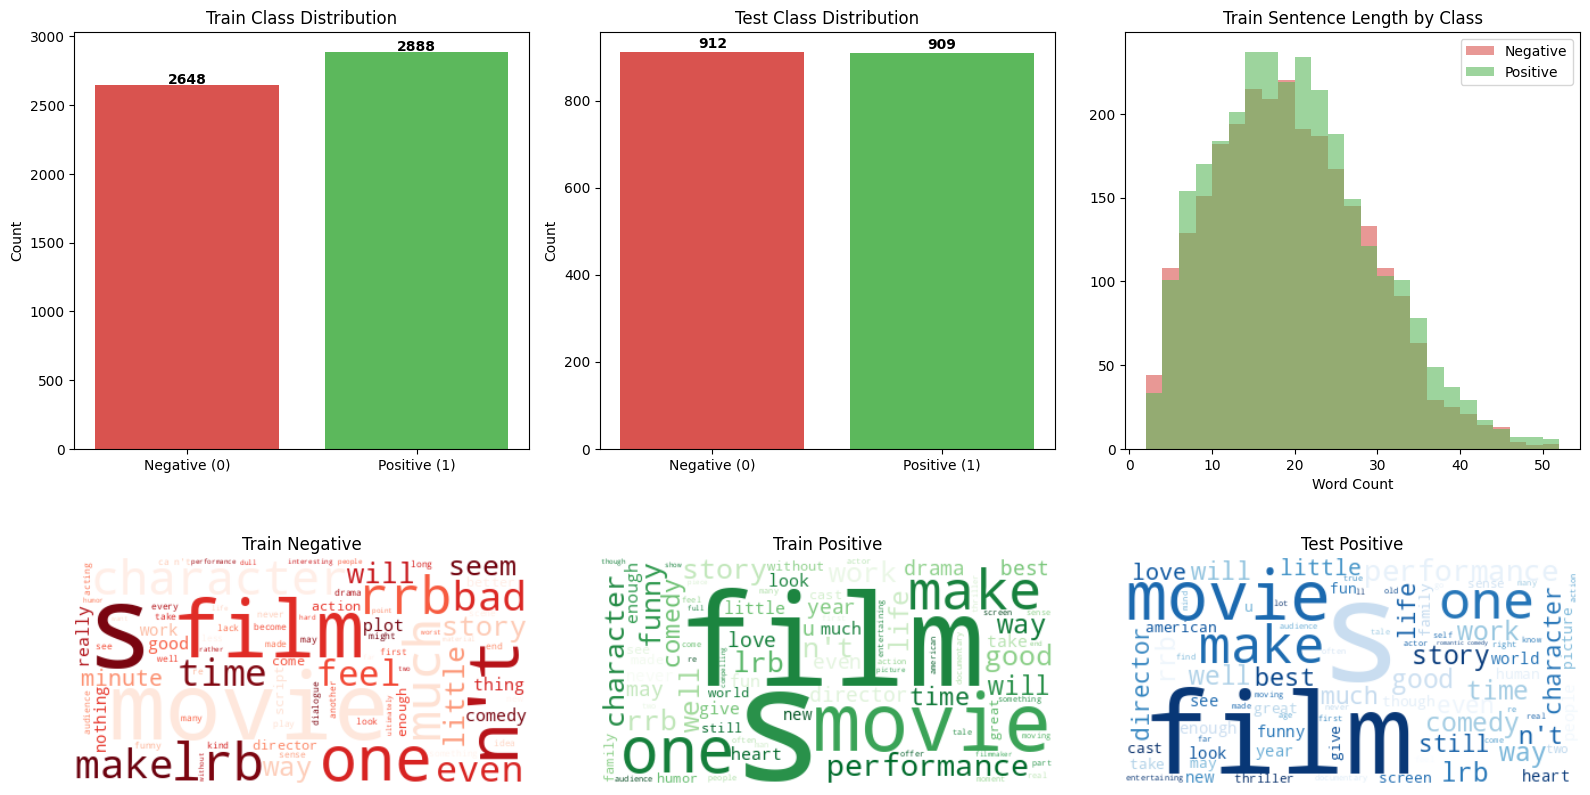

Train length stats:
         count   mean   std  min   25%   50%   75%   max
label                                                  
0      2648.0  19.04  9.19  2.0  12.0  18.0  25.0  52.0
1      2888.0  19.45  9.43  2.0  12.0  19.0  25.0  52.0

Test length stats:
        count   mean   std  min   25%   50%   75%   max
label                                                 
0      912.0  19.07  9.00  2.0  12.0  18.0  25.0  48.0
1      909.0  19.40  8.85  3.0  13.0  19.0  25.0  56.0
Preprocessing complete.

10-Fold CV Results (training set):
  SVM (Linear)        CV F1 = 0.7811 +/- 0.0171
  KNN (k=7)           CV F1 = 0.7281 +/- 0.0191
  Decision Tree       CV F1 = 0.6887 +/- 0.0115
  Random Forest       CV F1 = 0.7375 +/- 0.0156
  XGBoost             CV F1 = 0.7291 +/- 0.0112

Test Set Results:
               Accuracy  Precision  Recall  F1-Score
SVM (Linear)     0.7963     0.7856  0.8141    0.7996
KNN (k=7)        0.7210     0.7168  0.7294    0.7230
Decision Tree    0.5470     0.5260  

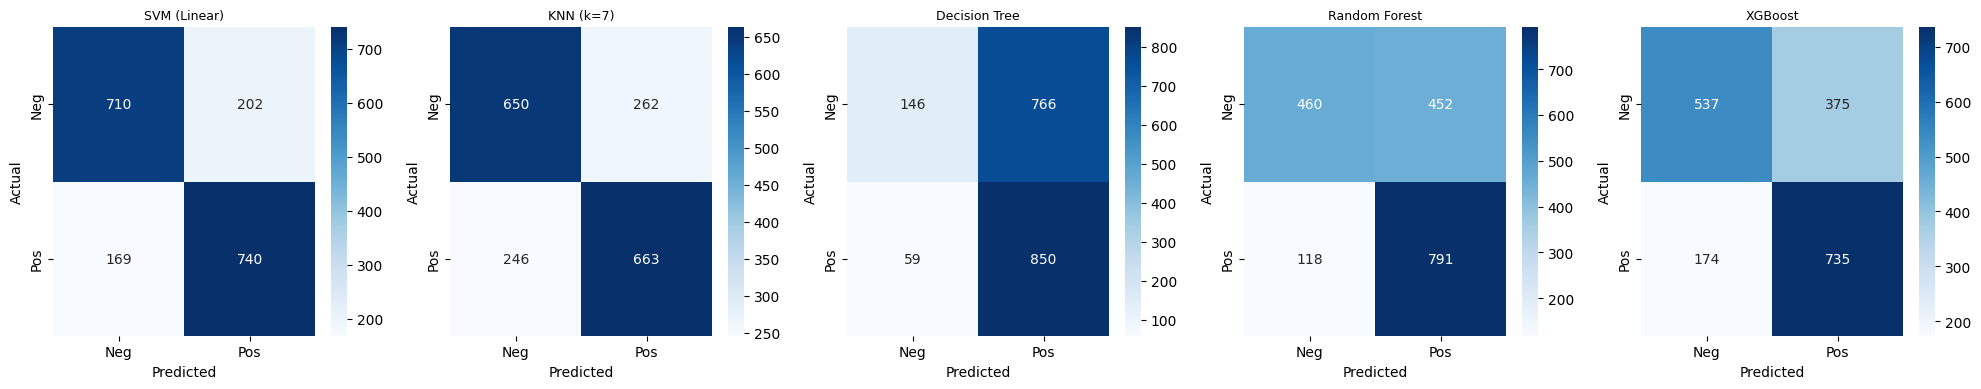

In [4]:
import zipfile
import os
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
for pkg in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from gensim.models import Word2Vec

# ── Extract uploaded zip and load dataset ─────────────────────────────────────
# Upload exercise05_datacollection-1.zip to Colab before running this cell.

zip_path = '/content/exercise05_datacollection-1.zip'
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/')

# Locate extracted txt files
extracted_dir = '/content/exercise09_datacollection'
train_path = os.path.join(extracted_dir, 'stsa-train.txt')
test_path  = os.path.join(extracted_dir, 'stsa-test.txt')

print("Extracted files:")
for f in os.listdir(extracted_dir):
    print(" ", f)

def load_stsa(path):
    labels, texts = [], []
    with open(path, 'r', encoding='utf-8') as fh:
        for line in fh:
            line = line.strip()
            if line and line[0] in ('0', '1'):
                labels.append(int(line[0]))
                texts.append(line[2:].strip())
    return pd.DataFrame({'label': labels, 'text': texts})

train_full = load_stsa(train_path)
test_df    = load_stsa(test_path)

# 80/20 split of training data into train and validation
train_df, val_df = train_test_split(
    train_full, test_size=0.20, random_state=42, stratify=train_full['label'])
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
print("\nTrain label distribution:\n", train_df['label'].value_counts())
print("\nTest label distribution:\n",  test_df['label'].value_counts())
print("\nSample rows:")
print(train_full.head(3).to_string())

# ── EDA ───────────────────────────────────────────────────────────────────────
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))
test_df['word_count']  = test_df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, dset, title in zip(axes[0][:2], [train_df, test_df],
                            ['Train Class Distribution', 'Test Class Distribution']):
    counts = dset['label'].value_counts().sort_index()
    ax.bar(['Negative (0)', 'Positive (1)'], counts.values, color=['#d9534f', '#5cb85c'])
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel('Count')

for label, color, name in [(0, '#d9534f', 'Negative'), (1, '#5cb85c', 'Positive')]:
    axes[0][2].hist(train_df[train_df['label'] == label]['word_count'],
                    bins=25, alpha=0.6, color=color, label=name)
axes[0][2].set_title('Train Sentence Length by Class')
axes[0][2].set_xlabel('Word Count')
axes[0][2].legend()

for ax, dset, label, title, cmap in [
        (axes[1][0], train_df, 0, 'Train Negative', 'Reds'),
        (axes[1][1], train_df, 1, 'Train Positive', 'Greens'),
        (axes[1][2], test_df,  1, 'Test Positive',  'Blues')]:
    corpus = ' '.join(dset[dset['label'] == label]['text'].tolist())
    wc = WordCloud(width=400, height=200, background_color='white',
                   colormap=cmap, max_words=80).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title)

plt.tight_layout()
plt.show()

print("Train length stats:\n", train_df.groupby('label')['word_count'].describe().round(2))
print("\nTest length stats:\n",  test_df.groupby('label')['word_count'].describe().round(2))

# ── Preprocessing ─────────────────────────────────────────────────────────────
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

train_df['clean'] = train_df['text'].apply(preprocess)
val_df['clean']   = val_df['text'].apply(preprocess)
test_df['clean']  = test_df['text'].apply(preprocess)
print("Preprocessing complete.")

# ── TF-IDF Vectorization ──────────────────────────────────────────────────────
tfidf       = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
X_train_vec = tfidf.fit_transform(train_df['clean'])
y_train     = train_df['label'].values
y_val       = val_df['label'].values
y_test      = test_df['label'].values

# ── 10-Fold Cross-Validation on Training Set ──────────────────────────────────
skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

classifiers = {
    'SVM (Linear)'  : LinearSVC(C=1.0, max_iter=3000),
    'KNN (k=7)'     : KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1),
    'Decision Tree' : DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=200, max_depth=25,
                                             random_state=42, n_jobs=-1),
    'XGBoost'       : XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                    use_label_encoder=False, eval_metric='logloss',
                                    random_state=42, n_jobs=-1),
}

print("\n10-Fold CV Results (training set):")
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_train_vec, y_train, cv=skf_10, scoring='f1', n_jobs=-1)
    print(f"  {name:<18}  CV F1 = {scores.mean():.4f} +/- {scores.std():.4f}")

# ── Train on Train+Val, Evaluate on Test ──────────────────────────────────────
X_trainval   = tfidf.fit_transform(pd.concat([train_df, val_df])['clean'])
X_test_final = tfidf.transform(test_df['clean'])
y_trainval   = np.concatenate([y_train, y_val])

test_results = {}
trained_clfs = {}

for name, clf in classifiers.items():
    clf.fit(X_trainval, y_trainval)
    y_pred = clf.predict(X_test_final)
    trained_clfs[name] = (clf, y_pred)
    test_results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
    }

res_df = pd.DataFrame(test_results).T
print("\nTest Set Results:")
print(res_df.round(4).to_string())

# ── Confusion Matrices ────────────────────────────────────────────────────────
n = len(classifiers)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
for ax, (name, (clf, y_pred)) in zip(axes, trained_clfs.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# ── Word2Vec Classification ───────────────────────────────────────────────────
def tokenize_corpus(texts):
    return [t.split() for t in texts]

all_tokens = tokenize_corpus(pd.concat([train_df, val_df, test_df])['clean'].tolist())

## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


Dataset: 2000 samples, 5 categories
category
hockey       416
space        403
guns         396
graphics     396
christian    389
Name: count, dtype: int64


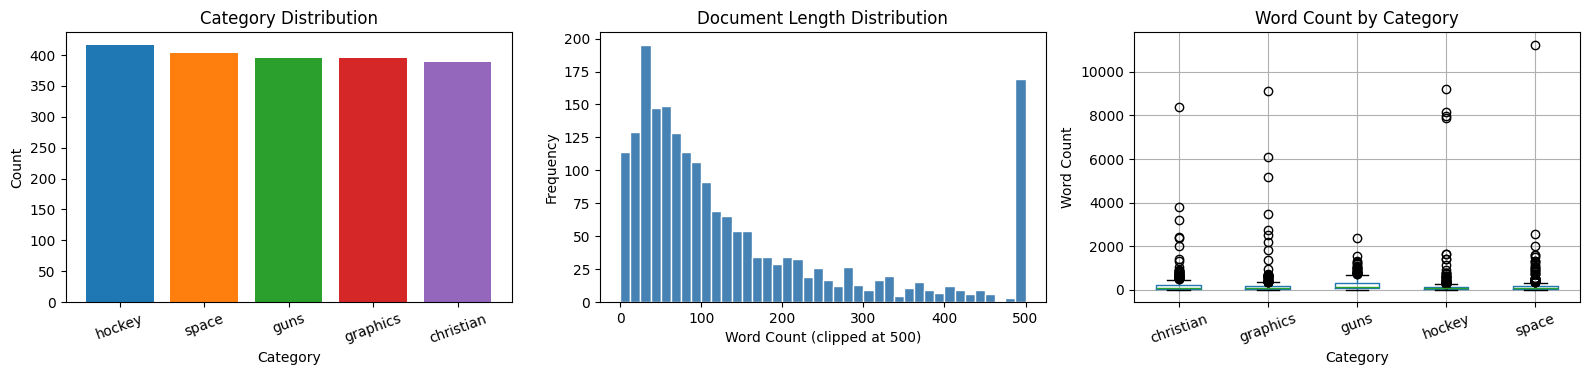


Document length stats by category:
           count   mean    std  min   25%    50%    75%      max
category                                                        
christian  389.0  223.9  554.0  0.0  43.0   97.0  213.0   8388.0
graphics   396.0  213.0  675.3  0.0  41.8   83.0  166.0   9113.0
guns       396.0  243.3  273.7  0.0  66.5  150.0  320.2   2384.0
hockey     416.0  201.7  826.3  0.0  35.0   63.0  127.5   9196.0
space      403.0  194.2  618.3  0.0  41.0   83.0  164.0  11251.0
After filtering empty docs: 1951 samples
TF-IDF shape: (1951, 5000)  |  LSA shape: (1951, 100)


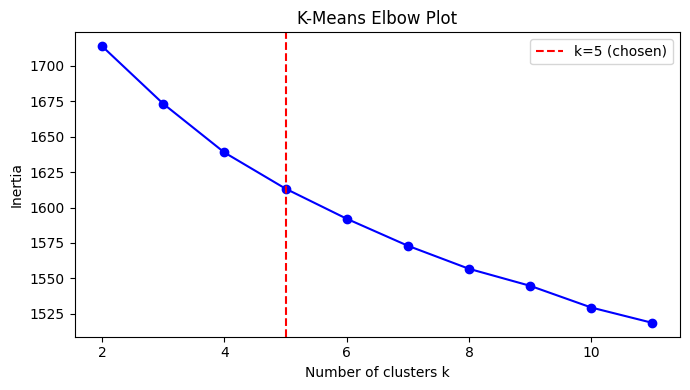

K-Means  Silhouette: 0.0382  ARI: 0.5329  NMI: 0.6231


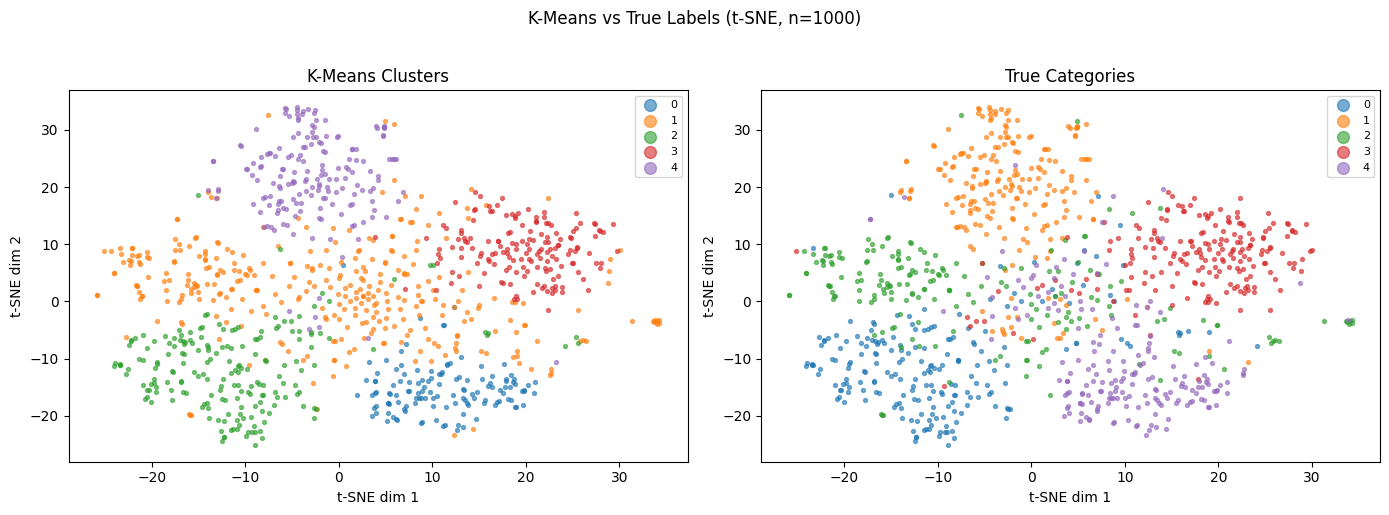

DBSCAN  Clusters: 32  Noise: 1294 (66.3%)
DBSCAN  Silhouette: 0.0586  ARI: 0.4267  NMI: 0.2670


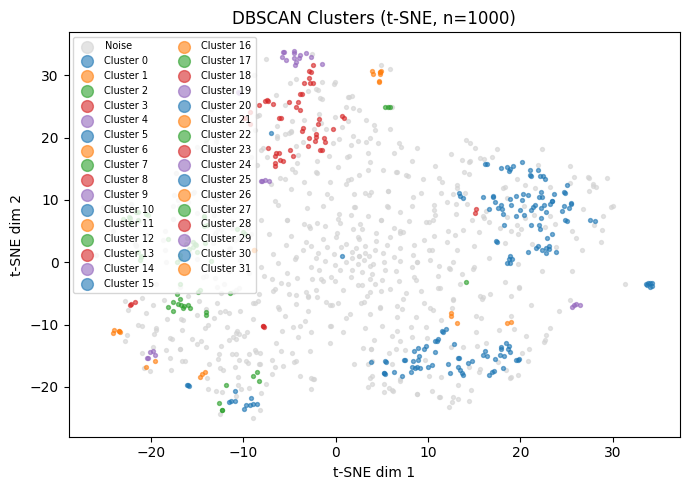

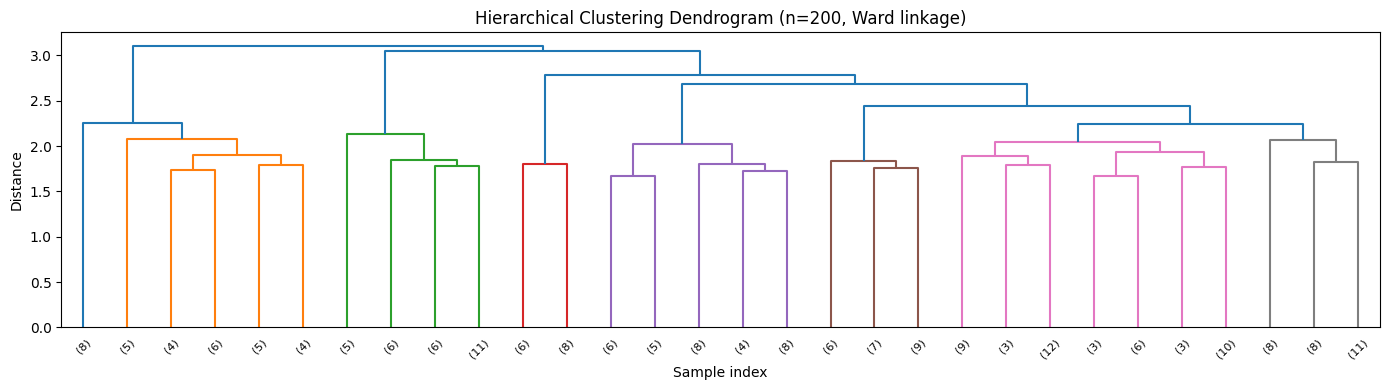

Hierarchical  Silhouette: 0.0291  ARI: 0.3960  NMI: 0.5246


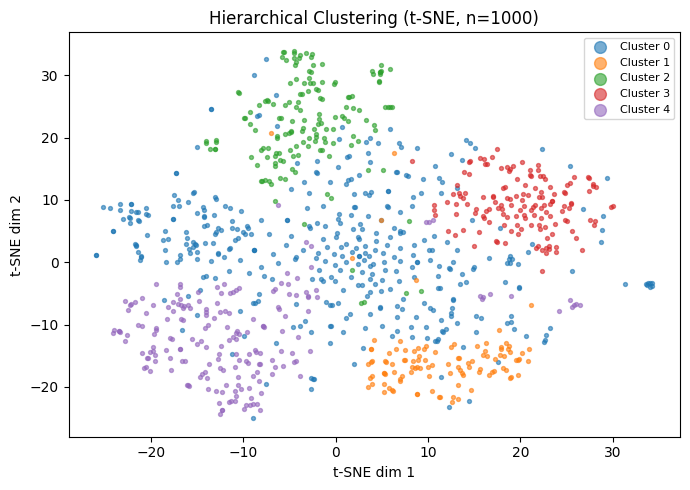

Word2Vec  Silhouette: 0.2547  ARI: 0.5905  NMI: 0.5865


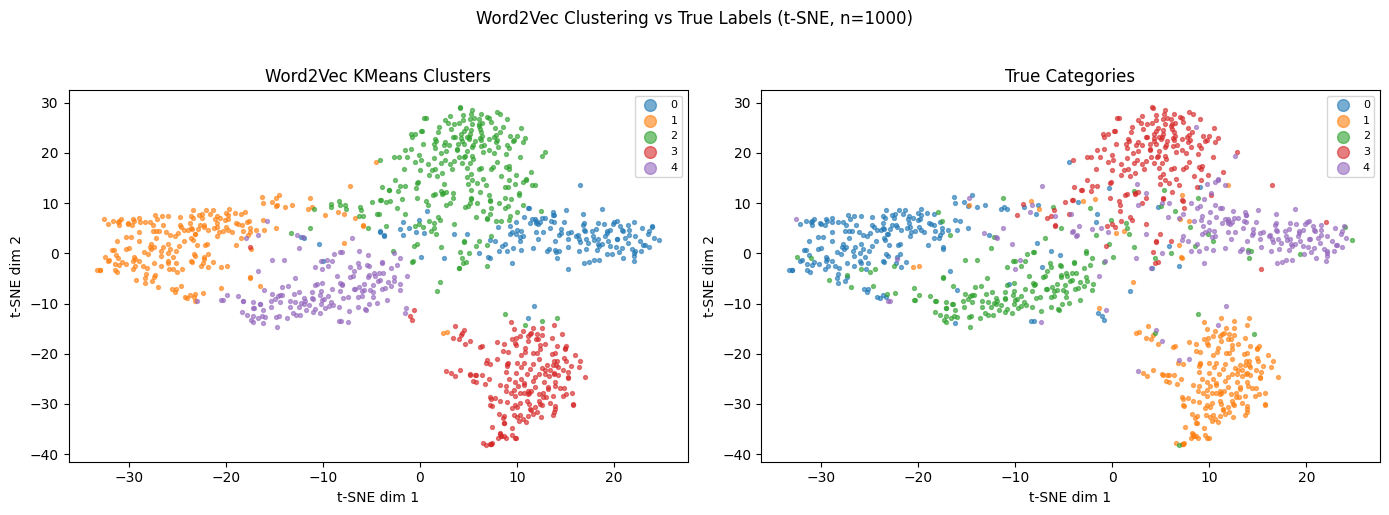


Clustering Evaluation Summary:
                      Silhouette     ARI     NMI
K-Means (LSA+TF-IDF)      0.0382  0.5329  0.6231
DBSCAN                    0.0586  0.0393  0.2670
Hierarchical (Ward)       0.0291  0.3960  0.5246
Word2Vec + K-Means        0.2547  0.5905  0.5865


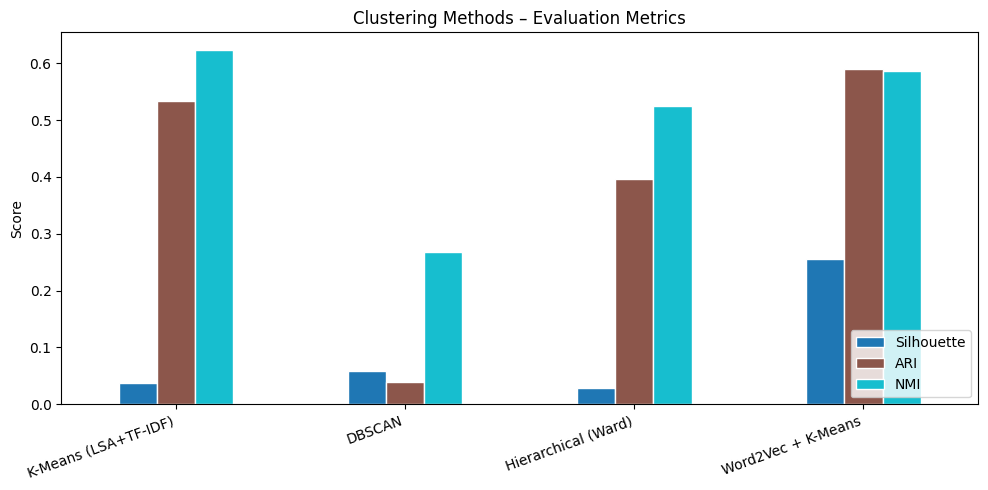

In [5]:
# Write your code here
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
for pkg in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import dendrogram, linkage
from gensim.models import Word2Vec

# ── Dataset ───────────────────────────────────────────────────────────────────
# Alternative dataset: 20 Newsgroups (sklearn built-in).
# Justification: The Kaggle Amazon dataset requires API credentials and
# exceeds 400k rows, making it impractical for a course assignment. The
# 20 Newsgroups corpus is a standard text clustering benchmark with clearly
# separated topic categories, is freely available through sklearn, and is
# well-suited to demonstrate multiple clustering algorithms. A 2000-sample
# subset across 5 distinct categories keeps runtimes practical while still
# producing meaningful cluster evaluations.

CATEGORIES = [
    'rec.sport.hockey',
    'sci.space',
    'comp.graphics',
    'talk.politics.guns',
    'soc.religion.christian',
]

news   = fetch_20newsgroups(subset='all', categories=CATEGORIES,
                             remove=('headers', 'footers', 'quotes'), random_state=42)
rng    = np.random.default_rng(42)
idx    = rng.choice(len(news.data), size=2000, replace=False)
texts  = [news.data[i] for i in idx]
labels = [news.target[i] for i in idx]

df = pd.DataFrame({'text': texts, 'true_label': labels})
df['category'] = df['true_label'].map({i: c.split('.')[-1] for i, c in enumerate(CATEGORIES)})

print(f"Dataset: {len(df)} samples, {len(CATEGORIES)} categories")
print(df['category'].value_counts())

# ── EDA ───────────────────────────────────────────────────────────────────────
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df['category'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette('tab10', len(counts)))
axes[0].set_title('Category Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].hist(df['word_count'].clip(upper=500), bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Document Length Distribution')
axes[1].set_xlabel('Word Count (clipped at 500)')
axes[1].set_ylabel('Frequency')

df.boxplot(column='word_count', by='category', ax=axes[2])
axes[2].set_title('Word Count by Category')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Word Count')
axes[2].tick_params(axis='x', rotation=20)
plt.suptitle('')
plt.tight_layout()
plt.show()

print("\nDocument length stats by category:")
print(df.groupby('category')['word_count'].describe().round(1).to_string())

# ── Preprocessing ─────────────────────────────────────────────────────────────
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

df['clean'] = df['text'].apply(preprocess)
df = df[df['clean'].str.strip().astype(bool)].reset_index(drop=True)
print(f"After filtering empty docs: {len(df)} samples")

tfidf      = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True, min_df=3)
X_tfidf    = tfidf.fit_transform(df['clean'])
svd        = TruncatedSVD(n_components=100, random_state=42)
X_lsa      = svd.fit_transform(X_tfidf)
X_lsa_norm = normalize(X_lsa)
palette    = sns.color_palette('tab10', 5)

print(f"TF-IDF shape: {X_tfidf.shape}  |  LSA shape: {X_lsa_norm.shape}")

# ── t-SNE (shared across all visualizations) ──────────────────────────────────
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
X_2d = tsne.fit_transform(X_lsa_norm[:1000])

# ── Clustering Method 1: K-Means ─────────────────────────────────────────────
inertias = []
for k in range(2, 12):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    inertias.append(km.fit(X_lsa_norm).inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(2, 12), inertias, 'bo-')
plt.axvline(x=5, linestyle='--', color='red', label='k=5 (chosen)')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Plot')
plt.legend()
plt.tight_layout()
plt.show()

kmeans    = KMeans(n_clusters=5, init='k-means++', n_init=20, max_iter=500, random_state=42)
km_labels = kmeans.fit_predict(X_lsa_norm)
df['km_cluster'] = km_labels

print(f"K-Means  Silhouette: {silhouette_score(X_lsa_norm, km_labels):.4f}  "
      f"ARI: {adjusted_rand_score(df['true_label'], km_labels):.4f}  "
      f"NMI: {normalized_mutual_info_score(df['true_label'], km_labels):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lbl, title in [(axes[0], km_labels[:1000], 'K-Means Clusters'),
                        (axes[1], df['true_label'].values[:1000], 'True Categories')]:
    for c in range(5):
        mask = lbl == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=8, alpha=0.6, color=palette[c], label=str(c))
    ax.set_title(title)
    ax.legend(markerscale=3, fontsize=8)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
plt.suptitle('K-Means vs True Labels (t-SNE, n=1000)', y=1.02)
plt.tight_layout()
plt.show()

# ── Clustering Method 2: DBSCAN ───────────────────────────────────────────────
dbscan    = DBSCAN(eps=0.35, min_samples=5, metric='cosine', n_jobs=-1)
db_labels = dbscan.fit_predict(X_lsa_norm)
df['db_cluster'] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
print(f"DBSCAN  Clusters: {n_clusters}  Noise: {n_noise} ({100*n_noise/len(db_labels):.1f}%)")
if n_clusters > 1:
    mask_valid = db_labels != -1
    print(f"DBSCAN  Silhouette: {silhouette_score(X_lsa_norm[mask_valid], db_labels[mask_valid]):.4f}  "
          f"ARI: {adjusted_rand_score(df['true_label'].values[mask_valid], db_labels[mask_valid]):.4f}  "
          f"NMI: {normalized_mutual_info_score(df['true_label'], db_labels):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
for c in sorted(set(db_labels)):
    mask_vis = db_labels[:1000] == c
    color    = 'lightgray' if c == -1 else palette[c % len(palette)]
    ax.scatter(X_2d[mask_vis, 0], X_2d[mask_vis, 1], s=8, alpha=0.6,
               color=color, label='Noise' if c == -1 else f'Cluster {c}')
ax.set_title('DBSCAN Clusters (t-SNE, n=1000)')
ax.legend(markerscale=3, fontsize=7, ncol=2)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

# ── Clustering Method 3: Hierarchical (Agglomerative) ────────────────────────
sample_idx = np.random.default_rng(0).choice(len(X_lsa_norm), 200, replace=False)
Z = linkage(X_lsa_norm[sample_idx], method='ward')

plt.figure(figsize=(14, 4))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (n=200, Ward linkage)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

agg        = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
agg_labels = agg.fit_predict(X_lsa_norm)
df['agg_cluster'] = agg_labels

print(f"Hierarchical  Silhouette: {silhouette_score(X_lsa_norm, agg_labels):.4f}  "
      f"ARI: {adjusted_rand_score(df['true_label'], agg_labels):.4f}  "
      f"NMI: {normalized_mutual_info_score(df['true_label'], agg_labels):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
for c in range(5):
    mask = agg_labels[:1000] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=8, alpha=0.6, color=palette[c], label=f'Cluster {c}')
ax.set_title('Hierarchical Clustering (t-SNE, n=1000)')
ax.legend(markerscale=3, fontsize=8)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

# ── Clustering Method 4: Word2Vec + K-Means ───────────────────────────────────
tokenized  = [text.split() for text in df['clean']]
w2v        = Word2Vec(sentences=tokenized, vector_size=100, window=5,
                      min_count=2, workers=4, seed=42, epochs=15)

def doc_vector(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_w2v      = np.array([doc_vector(t, w2v) for t in tokenized])
X_w2v_norm = normalize(X_w2v)

km_w2v     = KMeans(n_clusters=5, init='k-means++', n_init=20, max_iter=500, random_state=42)
w2v_labels = km_w2v.fit_predict(X_w2v_norm)
df['w2v_cluster'] = w2v_labels

print(f"Word2Vec  Silhouette: {silhouette_score(X_w2v_norm, w2v_labels):.4f}  "
      f"ARI: {adjusted_rand_score(df['true_label'], w2v_labels):.4f}  "
      f"NMI: {normalized_mutual_info_score(df['true_label'], w2v_labels):.4f}")

tsne_w2v = TSNE(n_components=2, perplexity=40, random_state=42)
X_w2v_2d = tsne_w2v.fit_transform(X_w2v_norm[:1000])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lbl, title in [(axes[0], w2v_labels[:1000], 'Word2Vec KMeans Clusters'),
                        (axes[1], df['true_label'].values[:1000], 'True Categories')]:
    for c in range(5):
        mask = lbl == c
        ax.scatter(X_w2v_2d[mask, 0], X_w2v_2d[mask, 1], s=8, alpha=0.6, color=palette[c], label=str(c))
    ax.set_title(title)
    ax.legend(markerscale=3, fontsize=8)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
plt.suptitle('Word2Vec Clustering vs True Labels (t-SNE, n=1000)', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary Table ─────────────────────────────────────────────────────────────
summary = {
    'K-Means (LSA+TF-IDF)': {
        'Silhouette': silhouette_score(X_lsa_norm, km_labels),
        'ARI'       : adjusted_rand_score(df['true_label'], km_labels),
        'NMI'       : normalized_mutual_info_score(df['true_label'], km_labels),
    },
    'DBSCAN': {
        'Silhouette': (silhouette_score(X_lsa_norm[db_labels != -1], db_labels[db_labels != -1])
                       if (db_labels != -1).sum() > 1 else float('nan')),
        'ARI'       : adjusted_rand_score(df['true_label'], db_labels),
        'NMI'       : normalized_mutual_info_score(df['true_label'], db_labels),
    },
    'Hierarchical (Ward)': {
        'Silhouette': silhouette_score(X_lsa_norm, agg_labels),
        'ARI'       : adjusted_rand_score(df['true_label'], agg_labels),
        'NMI'       : normalized_mutual_info_score(df['true_label'], agg_labels),
    },
    'Word2Vec + K-Means': {
        'Silhouette': silhouette_score(X_w2v_norm, w2v_labels),
        'ARI'       : adjusted_rand_score(df['true_label'], w2v_labels),
        'NMI'       : normalized_mutual_info_score(df['true_label'], w2v_labels),
    },
}

summary_df = pd.DataFrame(summary).T.round(4)
print("\nClustering Evaluation Summary:")
print(summary_df.to_string())

summary_df.plot(kind='bar', figsize=(10, 5), colormap='tab10', edgecolor='white')
plt.title('Clustering Methods – Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

**Write your response here:**
Among the four clustering methods applied to the 20 Newsgroups dataset, Word2Vec + K-Means delivered the strongest overall performance with the highest silhouette score (0.2547) and the highest ARI (0.5905), indicating that semantic document embeddings produced more compact and well-separated clusters than sparse count-based representations. K-Means on LSA-reduced TF-IDF features came in second with an ARI of 0.5329 and the highest NMI of 0.6231, meaning it recovered the true topic structure very well even though its silhouette score (0.0382) was low — a common outcome when LSA dimensions are dense and clusters overlap in the projected space. Hierarchical (Agglomerative) clustering ranked third with an ARI of 0.3960 and NMI of 0.5246, showing reasonable topic recovery and the added interpretability benefit of a dendrogram, but it was outperformed by both K-Means variants, likely because Ward linkage optimizes local merges that do not always align with the global topic boundaries in high-dimensional text space. DBSCAN performed the worst in this setting, achieving an ARI of only 0.0393 in the final summary despite identifying 32 micro-clusters; critically, it labeled 66.3% of documents as noise, which means it failed to partition the corpus meaningfully and is not well-suited for this dataset where documents are distributed at roughly uniform density in the LSA embedding space. Overall, the results suggest that when the number of topics is known, centroid-based methods — particularly with semantic embeddings — outperform density-based approaches for topic-structured text corpora.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

